In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

In [8]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [9]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [10]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="qwen/qwen3-vl-30b-a3b-thinking",
    base_url="https://openrouter.ai/api/v1",
    temperature=0.7,
    max_tokens=150,
    api_key="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",
)



In [11]:
os.getenv("OPENAI_BASE_URL")

'https://openrouter.ai/api/v1'

In [12]:
llm.invoke("hello")

AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 180, 'prompt_tokens': 11, 'total_tokens': 191, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 166, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': None, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-vl-30b-a3b-thinking', 'system_fingerprint': None, 'id': 'gen-1772084452-5ZwMkg41vXjz2dtx8mHb', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c9876-d905-7173-8631-5048a630f46a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 180, 'total_tokens': 191, 'input_token_details': {'

In [13]:
def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}  # must be a list

In [14]:
graphbuilder=StateGraph(State)
graphbuilder

In [15]:


graphbuilder.add_node("llmchatbot",chatbot)

graphbuilder.add_edge(START,"llmchatbot")
graphbuilder.add_edge("llmchatbot",END)


graph=graphbuilder.compile()

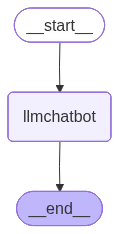

In [16]:
graph

In [17]:
# def rag(data):
#     print("RAG called with data:", data)
#     return True

In [18]:
# graphbuilder.add_node("RAG",rag)
# graphbuilder.add_edge("llmchatbot","RAG")
# graphbuilder.add_edge("RAG","llmchatbot")

In [19]:
# graph=graphbuilder.compile()

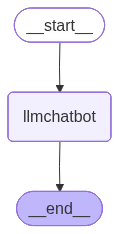

In [20]:
graph

In [21]:
graph.invoke({"messages":"hi i am kunal"})

{'messages': [HumanMessage(content='hi i am kunal', additional_kwargs={}, response_metadata={}, id='62b4f4a0-d474-4a01-8c42-1782bd6f200b'),
  AIMessage(content='Hi Kunal! Nice to meet you. How can I assist you today? 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 287, 'prompt_tokens': 15, 'total_tokens': 302, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 266, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': None, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-vl-30b-a3b-thinking', 'system_fingerprint': None, 'id': 'gen-1772084457-OwdNkKpeid9UccgI0XnB', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c9876-ee9b-79f2-a

In [22]:
graph.invoke({"messages":"what is my name"})

{'messages': [HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='39563e88-d47b-4326-ab70-30f0becb4665'),
  AIMessage(content='I don\'t have access to your personal information or any memory of past conversations unless you share it with me directly in the current chat. **I don\'t know your name** because I don\'t store personal data between sessions, and I can\'t see or recall details about you unless you tell me.  \n\nIf you\'d like to share your name (or a nickname you prefer), I’d be happy to use it going forward! Just say something like:  \n> *"My name is [Your Name]."*  \n\nOtherwise, I\'ll keep things simple and friendly—no pressure. 😊 Let me know how you\'d like to proceed!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 397, 'prompt_tokens': 14, 'total_tokens': 411, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 266, 'rejected_predicti

In [3]:
from langchain_tavily import TavilySearch
from openai import api_key

tool=TavilySearch(max_results=3)
tool.invoke("What is the claude skills")

{'query': 'What is the claude skills',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://medium.com/@bijit211987/claude-skills-the-operating-system-for-ai-agents-9cadb1881b90',
   'title': 'Claude Skills, The Operating System for AI Agents | by Bijit Ghosh',
   'content': '# Claude Skills, The Operating System for AI Agents. Claude Skills, introduced by Anthropic, is one of those moments. Claude Skills are small, self-contained modules that describe how to perform a specific task. When a user asks Claude to do something, it doesn’t load every Skill. Claude Skills are built on plain Markdown and YAML. For example, a Skill might help Claude process raw CSV data, generate a summary, and validate it for formatting errors — all autonomously within a secure sandbox. Imagine configuring a few Skills that help Claude:. Claude Skills follow the same philosophy. The Future: Skill Composition as an AI Operating Model. Claude Skills mirror how humans opera

In [23]:
def multiply(a:int,b:int)->int:
    """Multiply a and b
    
    Args:
    a (int): first number
    b (int): second number
    
    Returns:
    int: the product of a and b
    """
    return a*b

In [24]:
tools=[tool,multiply]

In [25]:
llm_with_tools=llm.bind_tools(tools)

In [26]:
llm_with_tools

RunnableBinding(bound=ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002747D467790>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002747DB2E750>, root_client=<openai.OpenAI object at 0x000002747D466ED0>, root_async_client=<openai.AsyncOpenAI object at 0x000002747DB2E410>, model_name='qwen/qwen3-vl-30b-a3b-thinking', temperature=0.7, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1', max_tokens=150), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.In

In [29]:
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition



In [30]:
def tool_calling_llm(state:State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}  # must be a list

In [35]:
builder= StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))



builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition

)

builder.add_edge("tools",END)
graph=builder.compile()


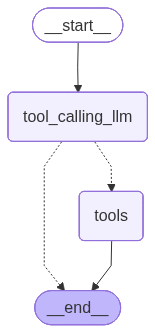

In [36]:
graph

In [37]:
graph.invoke({"messages":"What is recent AI news?"})

{'messages': [HumanMessage(content='What is recent AI news?', additional_kwargs={}, response_metadata={}, id='6fff4ff3-e1e1-48b6-b91b-a87c0c69b876'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1012, 'prompt_tokens': 1774, 'total_tokens': 2786, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 966, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': None, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-vl-30b-a3b-thinking', 'system_fingerprint': None, 'id': 'gen-1772089215-xjAreubHt1OmrOFWkkfQ', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c98bf-86a7-7830-9918-17fc37f5b129-0', tool_calls=[{'na